# char_01 — What is in the charcoal / biochar FTIR archive, collection by collection

## Purpose

Six published FTIR collections were pulled into
`research/ftir_hips_chem/charcoal_ftir_sources/` (see its `README.md` for DOIs and
licenses). This notebook is the **survey**: it loads all six, harmonizes their
metadata, and plots each one on its own terms so the next notebook
(`char_02`) can compare them against the Addis Ababa filter spectra without
re-litigating what any given file contains.

The archive holds **5,889 spectra** across four different wavenumber grids, two
different value scales, 27 plant species/feedstocks, and pyrolysis temperatures from
unburned feedstock to 800 °C.

## What needs harmonizing before anything can be plotted together

1. **Four wavenumber grids.** Minatre (0.96 cm⁻¹), Maezumi (≈2 cm⁻¹ decimated),
   McCall (2 cm⁻¹, two different spans), WDG (1.93 cm⁻¹). Everything is resampled onto
   one grid over the region all six share, **951–3500 cm⁻¹**.
2. **Two value scales.** Minatre and McCall ship as absorbance — and differ from each
   other by ~30× in absolute magnitude, because one is a KBr pellet and the other is
   thickness-normalized ATR. Maezumi and WDG ship **already SNV-normalized**
   (each spectrum centred to mean 0, sd 1). That was verified numerically here rather
   than taken from the papers, and it matters: SNV is shape-preserving, so applying it
   to the absorbance collections puts all six on one legitimate footing.
3. **Two of the six have no temperature label.** The Minatre combustion-facility burns
   and the WDG Lake Ayauchi fossil fragments are the *application* sets in their source
   papers — the material whose temperature the reference series exists to predict. They
   are carried through here as unlabeled, never mixed into temperature summaries.

## Takeaways

See the end of the notebook — they are written against the figures below.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

from charcoal_spectra import (
    load_all, snv, common_grid, resample, band_area, band_table,
    BANDS, CHARCOAL_OVERLAP,
)

PLOT_DIR = Path("output/plots/char01")
TABLE_DIR = Path("output/tables/char01")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

# Categorical slots (validated: adjacent CVD ΔE 9.1, normal-vision 19.6 on a light
# surface). Three of these sit under 3:1 contrast, so every panel is directly titled
# and every figure is backed by a table — the relief rule, not color alone.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"

# Temperature is a magnitude, so it gets a single-hue sequential ramp (light -> dark),
# not a rainbow. Warm hue because the quantity is heat.
TEMP_CMAP = plt.get_cmap("Reds")


def temp_color(t, lo=0.0, hi=800.0):
    """Light->dark within one hue; floor at 0.25 so the palest step stays visible."""
    return TEMP_CMAP(0.25 + 0.70 * (np.clip(t, lo, hi) - lo) / (hi - lo))

## Load all six collections

Every loader returns the same `SpectralSet` record — spectra ascending in wavenumber,
plus a `meta` frame with harmonized `sample` / `species` / `temp_c` / `treatment` /
`rep` columns. The per-file quirks (BOM-prefixed headers, 95 collided wavenumber
labels in the Minatre reference file, a stray `W_` prefix in Maezumi, temperature
hidden inside sample names in McCall-barley, WDG stored one spectrum per *column*)
are all absorbed in `scripts/charcoal_spectra.py`.

In [2]:
sets = load_all()

inventory = pd.DataFrame([
    {
        "collection": s.label,
        "key": k,
        "n spectra": s.n,
        "species / feedstocks": s.meta["species"].nunique(),
        "temperatures": (
            "unlabeled" if s.meta["temp_c"].notna().sum() == 0
            else f"{s.meta['temp_c'].min():.0f}–{s.meta['temp_c'].max():.0f} °C "
                 f"({s.meta['temp_c'].nunique()} levels)"
        ),
        "range (cm⁻¹)": f"{s.wn.min():.0f}–{s.wn.max():.0f}",
        "points": s.wn.size,
        "native scale": s.native_scale,
    }
    for k, s in sets.items()
])
display(inventory)
print(f"\nTotal spectra in the archive: {inventory['n spectra'].sum():,}")
inventory.to_csv(TABLE_DIR / "inventory.csv", index=False)

,collection,key,n spectra,species / feedstocks,temperatures,range (cm⁻¹),points,native scale
0,Minatre — muffle-furnace reference,minatre_ref,2100,10,200–800 °C (7 levels),950–3500,2646,absorbance
1,Minatre — combustion facility,minatre_burn,1934,4,unlabeled,950–3500,2646,absorbance
2,Maezumi — modern analogue reference,maezumi,1260,9,200–700 °C (6 levels),951–3500,1323,snv
3,McCall — six feedstocks,mccall_multi,162,6,0–700 °C (9 levels),600–3701,1609,absorbance
4,McCall — barley straw series,mccall_barley,78,1,0–700 °C (13 levels),550–4000,1790,absorbance
5,Gosling — grass/alder + Ayauchi fossil,wdg,355,3,200–700 °C (6 levels),750–3599,1478,snv



Total spectra in the archive: 5,889


## 1. What each file actually contains, in its own units

Before any harmonization — every spectrum, on its native grid and native scale. This
is the figure that shows *why* harmonization is needed: the y-axes are not
comparable across panels, and two panels are not even absorbance. Where temperature
is known the spectra are colored by it on a single-hue light→dark ramp; the two
unlabeled collections are drawn in grey.

Collections are subsampled to at most 400 spectra per panel purely so the figure
renders — the subsample is drawn with a fixed seed and the panel notes the full count.

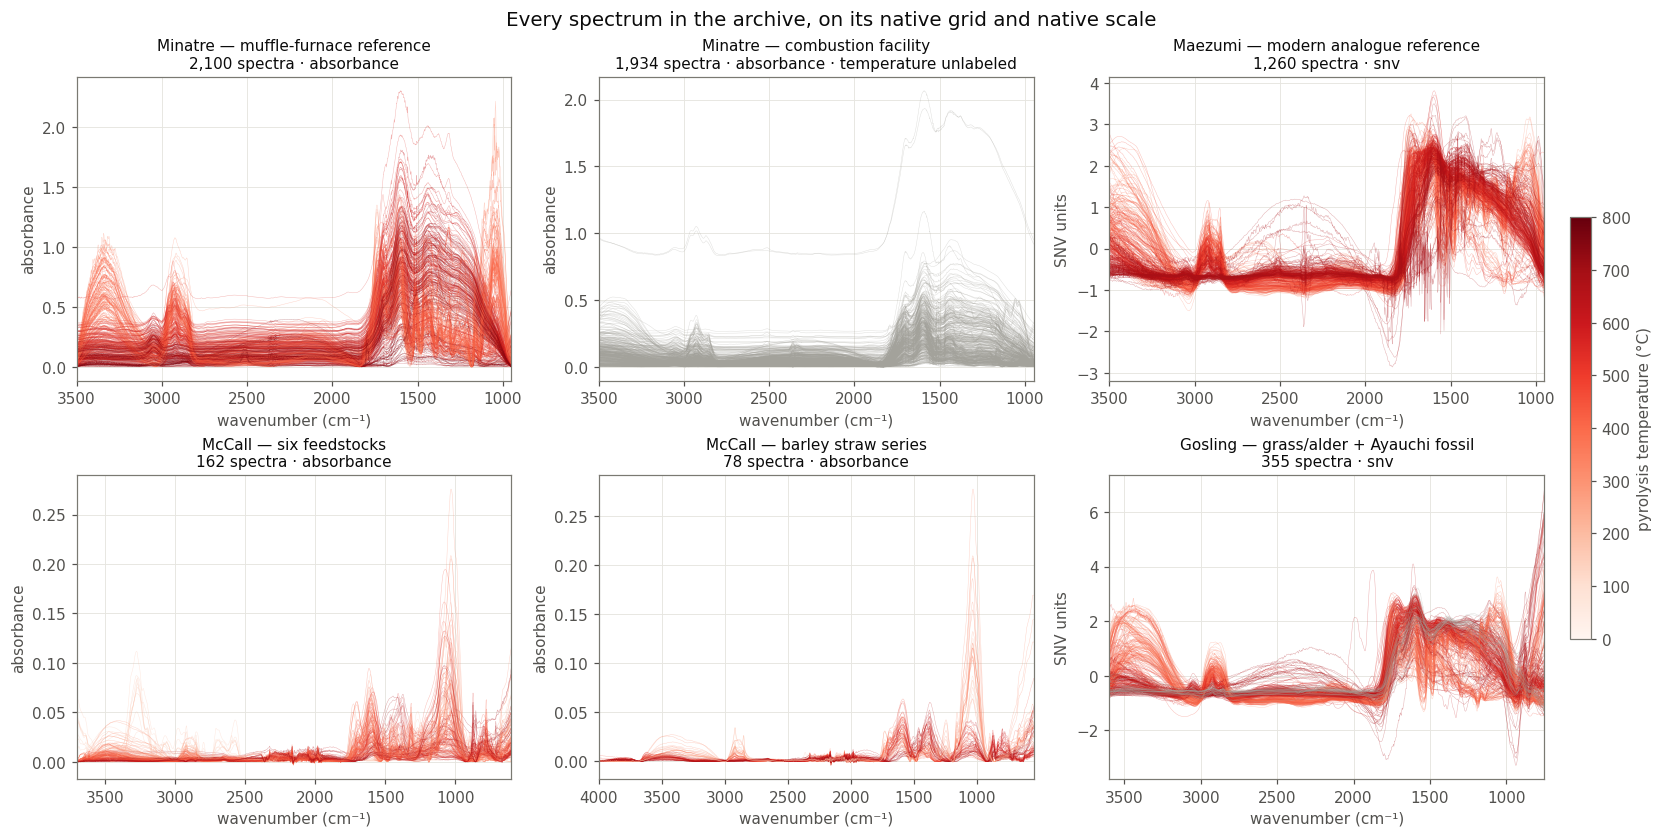

In [3]:
MAX_DRAW = 400

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), constrained_layout=True)
for ax, (key, s) in zip(axes.ravel(), sets.items()):
    idx = np.arange(s.n)
    if s.n > MAX_DRAW:
        idx = np.sort(rng.choice(idx, MAX_DRAW, replace=False))
    temps = s.meta["temp_c"].to_numpy(float)
    labelled = np.isfinite(temps).any()
    for i in idx:
        c = temp_color(temps[i]) if labelled and np.isfinite(temps[i]) else MUTED
        ax.plot(s.wn, s.X[i], color=c, lw=0.3, alpha=0.35, rasterized=True)
    ax.set_title(f"{s.label}\n{s.n:,} spectra · {s.native_scale}"
                 + ("" if labelled else " · temperature unlabeled"),
                 color=INK, fontsize=10)
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
    ax.set_ylabel("absorbance" if s.native_scale == "absorbance" else "SNV units",
                  color=INK2)
    ax.set_xlim(s.wn.max(), s.wn.min())  # spectroscopy convention: high -> low

sm = plt.cm.ScalarMappable(cmap=TEMP_CMAP, norm=plt.Normalize(0, 800))
cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.6, pad=0.01)
cbar.set_label("pyrolysis temperature (°C)", color=INK2)
fig.suptitle("Every spectrum in the archive, on its native grid and native scale",
             fontsize=13, color=INK)
fig.savefig(PLOT_DIR / "01_native_overview.png", dpi=160, bbox_inches="tight")
plt.show()

The two SNV panels (Maezumi, Gosling) are visibly centred on zero and swing negative;
the four absorbance panels sit above zero. Within the absorbance panels, note that the
Minatre y-range runs to ~3 while McCall tops out near 0.28 — a ~30× difference that is
instrument geometry, not chemistry.

## 2. Harmonize: one grid, one scale

Resample onto a 2 cm⁻¹ grid across 951–3500 cm⁻¹ (the region all six share), then SNV
every collection. SNV removes the additive baseline offset and the multiplicative
path-length term, which is precisely the pair of nuisances that separate a KBr pellet
of bulk charcoal from thickness-normalized ATR — and, later, from micrograms of
aerosol on a PTFE filter.

In [4]:
grid = common_grid(step=2.0, window=CHARCOAL_OVERLAP)
H = {}
for key, s in sets.items():
    Xr = resample(s.X, s.wn, grid)
    keep = np.isfinite(Xr).all(axis=1)
    H[key] = {"X": snv(Xr[keep]), "meta": s.meta.loc[keep].reset_index(drop=True),
              "label": s.label, "short": s.short}
    if (~keep).any():
        print(f"{key}: dropped {(~keep).sum()} spectra not covering the full grid")

print(f"\nharmonized grid: {grid.min():.0f}–{grid.max():.0f} cm⁻¹, {grid.size} points")
print("harmonized counts:", {k: v['X'].shape[0] for k, v in H.items()})


harmonized grid: 951–3499 cm⁻¹, 1275 points
harmonized counts: {'minatre_ref': 2100, 'minatre_burn': 1934, 'maezumi': 1260, 'mccall_multi': 162, 'mccall_barley': 78, 'wdg': 355}


## 3. The charring sequence, collection by collection

Mean SNV spectrum at each temperature level, with the interquartile band across
replicates. Read left to right within a panel and the same story repeats in every
labeled collection: the O–H/N–H envelope near 3300 and the aliphatic C–H doublet near
2920 collapse as temperature rises, while the aromatic C=C band near 1600 sharpens and
grows. That is the fingerprint of aromatization.

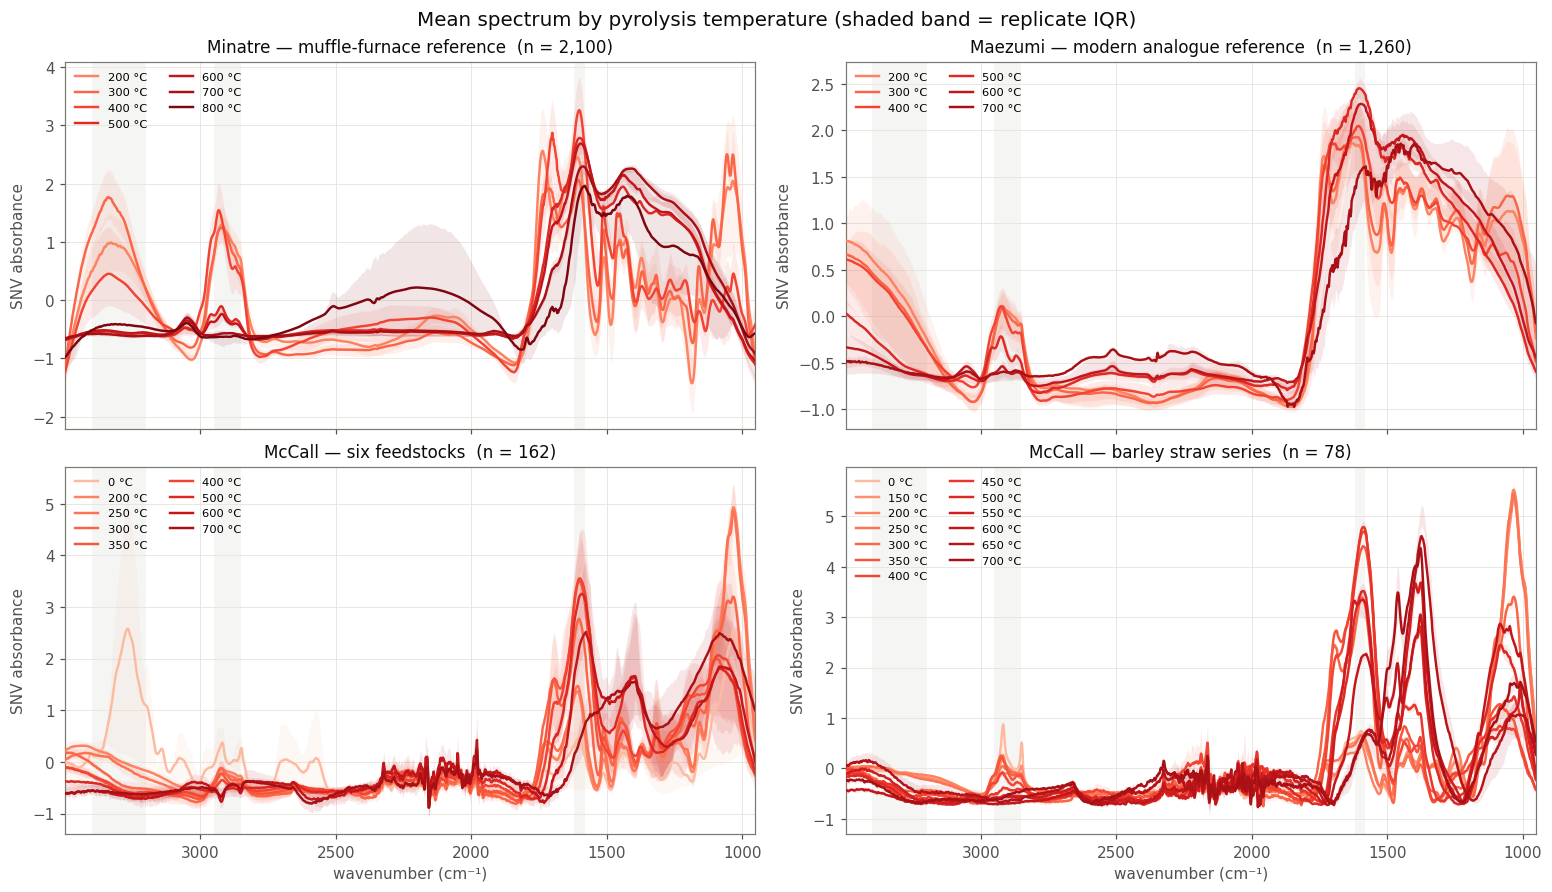

In [5]:
labelled_keys = [k for k, v in H.items() if v["meta"]["temp_c"].notna().any()]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True, sharex=True)
for ax, key in zip(axes.ravel(), labelled_keys):
    X, meta = H[key]["X"], H[key]["meta"]
    for t in sorted(meta["temp_c"].dropna().unique()):
        m = (meta["temp_c"] == t).to_numpy()
        ax.plot(grid, X[m].mean(0), color=temp_color(t), lw=1.6,
                label=f"{t:.0f} °C", zorder=3)
        q1, q3 = np.percentile(X[m], [25, 75], axis=0)
        ax.fill_between(grid, q1, q3, color=temp_color(t), alpha=0.10, lw=0)
    for lo, hi in (BANDS["aromatic C=C"], BANDS["aliphatic CH stretch"],
                   BANDS["OH / NH stretch"]):
        ax.axvspan(lo, hi, color=MUTED, alpha=0.10, lw=0, zorder=0)
    ax.set_title(f"{H[key]['label']}  (n = {X.shape[0]:,})", color=INK)
    ax.set_xlim(grid.max(), grid.min())
    ax.set_ylabel("SNV absorbance", color=INK2)
    ax.legend(fontsize=7.5, ncol=2, loc="upper left")
for ax in axes[-1]:
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
fig.suptitle("Mean spectrum by pyrolysis temperature (shaded band = replicate IQR)",
             fontsize=13, color=INK)
fig.savefig(PLOT_DIR / "02_mean_by_temperature.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. The two unlabeled collections

The Minatre combustion-facility burns (by species) and the Gosling Lake Ayauchi fossil
fragments (by core depth) have no temperature to plot against — they are the material
their source papers predict *onto*. Shown here by their own grouping variable, against
the envelope of the labeled reference material for scale.

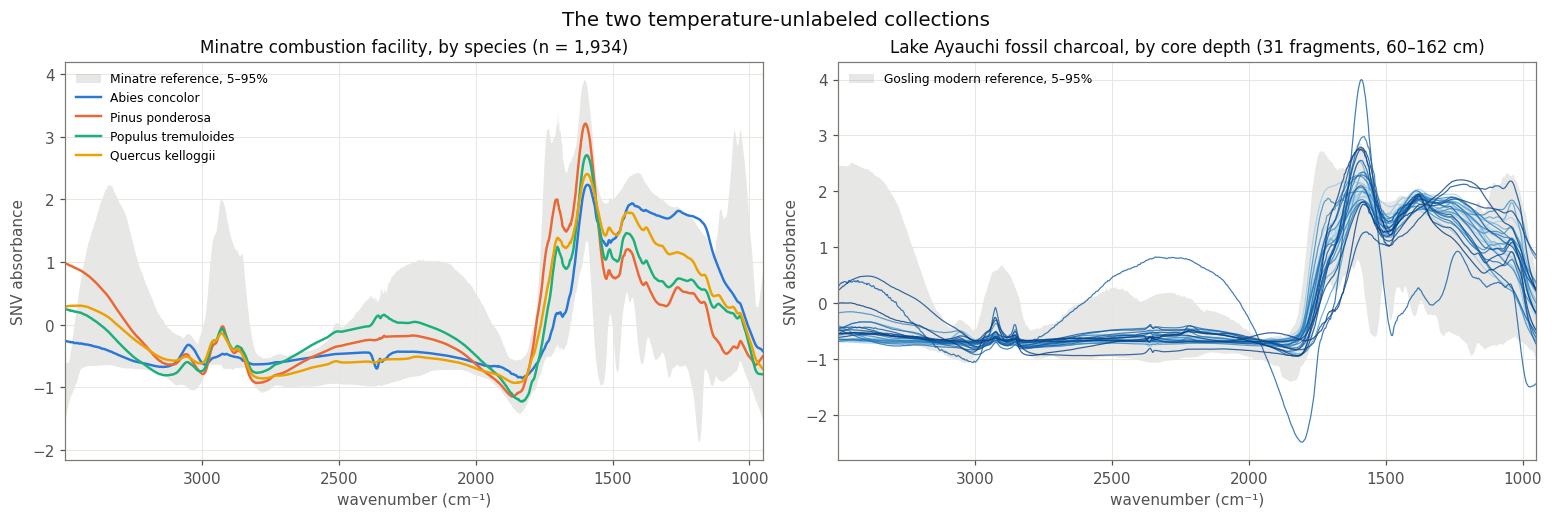

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)

ref_all = H["minatre_ref"]["X"]
lo_env, hi_env = np.percentile(ref_all, [5, 95], axis=0)

ax = axes[0]
ax.fill_between(grid, lo_env, hi_env, color=MUTED, alpha=0.25, lw=0,
                label="Minatre reference, 5–95%", zorder=0)
bm = H["minatre_burn"]["meta"]
for i, sp in enumerate(sorted(bm["species"].dropna().unique())):
    m = (bm["species"] == sp).to_numpy()
    ax.plot(grid, H["minatre_burn"]["X"][m].mean(0), color=SERIES[i], lw=1.6, label=sp)
ax.set_title(f"Minatre combustion facility, by species (n = {bm.shape[0]:,})", color=INK)

ax = axes[1]
wm = H["wdg"]["meta"]
modern = wm["temp_c"].notna().to_numpy()
lo_w, hi_w = np.percentile(H["wdg"]["X"][modern], [5, 95], axis=0)
ax.fill_between(grid, lo_w, hi_w, color=MUTED, alpha=0.25, lw=0,
                label="Gosling modern reference, 5–95%", zorder=0)
fossil = wm["is_fossil"].fillna(False).to_numpy(bool)
depths = wm.loc[fossil, "depth_cm"].to_numpy(float)
Xf = H["wdg"]["X"][fossil]
d_lo, d_hi = np.nanmin(depths), np.nanmax(depths)
for i in range(Xf.shape[0]):
    shade = plt.get_cmap("Blues")(0.25 + 0.70 * (depths[i] - d_lo) / (d_hi - d_lo))
    ax.plot(grid, Xf[i], color=shade, lw=0.8, alpha=0.8)
ax.set_title(f"Lake Ayauchi fossil charcoal, by core depth "
             f"({int(fossil.sum())} fragments, {d_lo:.0f}–{d_hi:.0f} cm)", color=INK)

for ax in axes:
    ax.set_xlim(grid.max(), grid.min())
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
    ax.set_ylabel("SNV absorbance", color=INK2)
    ax.legend(fontsize=8, loc="upper left")
fig.suptitle("The two temperature-unlabeled collections", fontsize=13, color=INK)
fig.savefig(PLOT_DIR / "03_unlabeled_sets.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Does the charring trajectory agree across collections?

If these six independent studies are measuring the same physical process, the
diagnostic bands should move the same way in all of them. Three bands, one panel each,
one line per collection.

The answer is **yes, but only two of the three bands are monotonic** — and that
distinction turns out to govern everything the rest of this project can do.

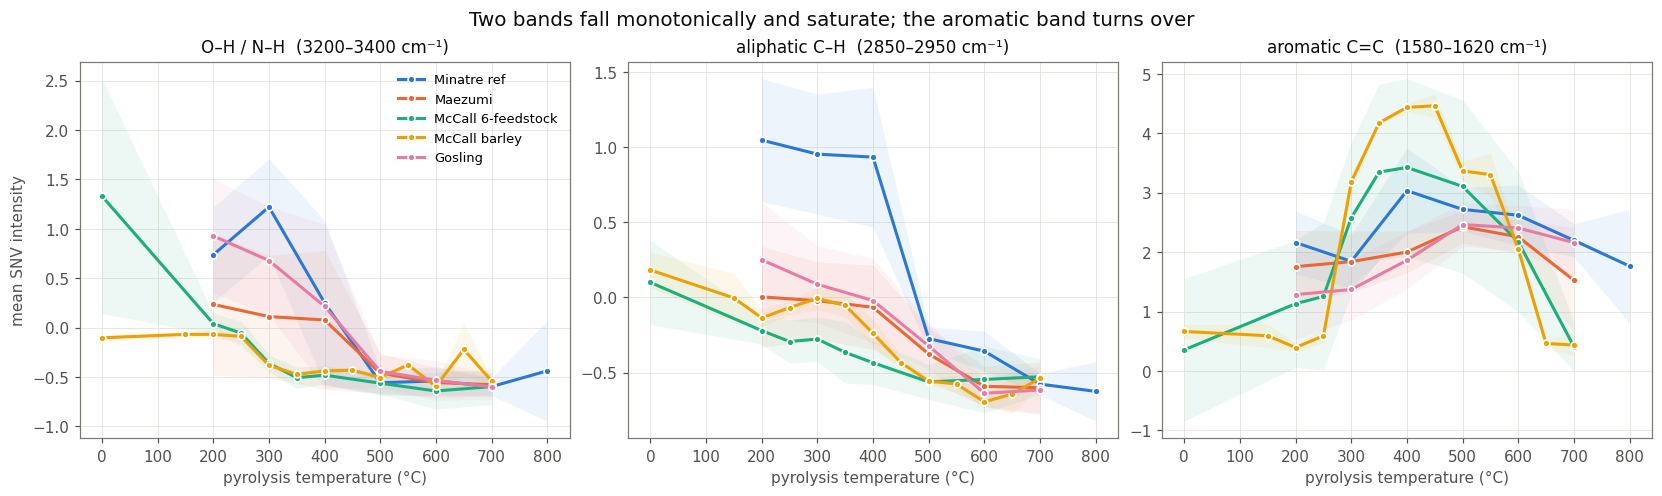

In [7]:
traj = []
for key in labelled_keys:
    X, meta = H[key]["X"], H[key]["meta"]
    arom = band_area(X, grid, BANDS["aromatic C=C"])
    aliph = band_area(X, grid, BANDS["aliphatic CH stretch"])
    oh = band_area(X, grid, BANDS["OH / NH stretch"])
    traj.append(pd.DataFrame({
        "collection": H[key]["short"], "key": key, "temp_c": meta["temp_c"],
        "aromatic_minus_aliphatic": arom - aliph,
        "aromatic C=C": arom, "aliphatic C–H": aliph, "O–H / N–H": oh,
    }))
traj = pd.concat(traj, ignore_index=True).dropna(subset=["temp_c"])

PANEL_BANDS = ["O–H / N–H", "aliphatic C–H", "aromatic C=C"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True, sharex=True)
for ax, band in zip(axes, PANEL_BANDS):
    for i, key in enumerate(labelled_keys):
        g = traj[traj["key"] == key].groupby("temp_c")[band].agg(["mean", "std"])
        ax.plot(g.index, g["mean"], color=SERIES[i], lw=2, marker="o", ms=4.5,
                markeredgecolor="white", markeredgewidth=1.1, zorder=3,
                label=H[key]["short"])
        ax.fill_between(g.index, g["mean"] - g["std"], g["mean"] + g["std"],
                        color=SERIES[i], alpha=0.08, lw=0)
    ax.set_title(f"{band}  ({BANDS[{'O–H / N–H': 'OH / NH stretch', 'aliphatic C–H': 'aliphatic CH stretch', 'aromatic C=C': 'aromatic C=C'}[band]][0]}–"
                 f"{BANDS[{'O–H / N–H': 'OH / NH stretch', 'aliphatic C–H': 'aliphatic CH stretch', 'aromatic C=C': 'aromatic C=C'}[band]][1]} cm⁻¹)",
                 color=INK)
    ax.set_xlabel("pyrolysis temperature (°C)", color=INK2)
    ax.set_xlim(-40, 840)
axes[0].set_ylabel("mean SNV intensity", color=INK2)
axes[0].legend(fontsize=8.5, loc="upper right")
fig.suptitle("Two bands fall monotonically and saturate; the aromatic band turns over",
             fontsize=13, color=INK)
fig.savefig(PLOT_DIR / "04_band_trajectories.png", dpi=160, bbox_inches="tight")
plt.show()

**The O–H/N–H and aliphatic C–H bands fall monotonically in all five labeled
collections** — and then flatten out around −0.6 SNV units by roughly 500–600 °C.
Below that they are informative; above it they are saturated and carry no temperature
signal at all.

**The aromatic C=C band is not monotonic.** It climbs to a maximum somewhere between
300 and 500 °C depending on the collection, then falls — steeply in the McCall series,
which drop from ~4.4 at 450 °C to ~0.4 at 700 °C. That is consistent with the char
becoming graphitic at high temperature: the broad electronic continuum grows and
discrete bands weaken against it, so after per-spectrum normalization the 1600 cm⁻¹
feature shrinks even though aromatic carbon is still increasing.

The consequence is the important part. A composite aromatization index built from
these bands is **two-valued in temperature** — a given value can mean a moderately
charred sample or a heavily charred one:

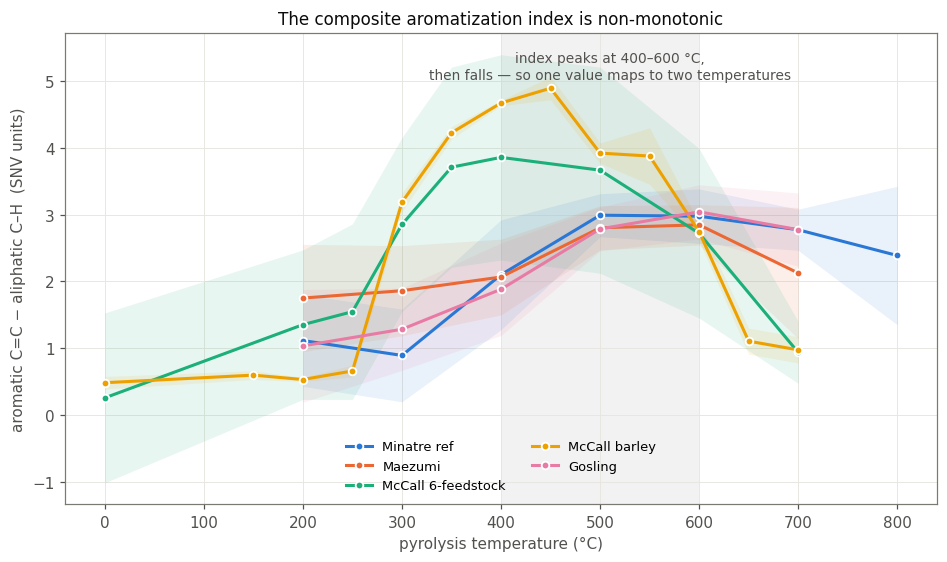

collection,Gosling,Maezumi,McCall 6-feedstock,McCall barley,Minatre ref
temp_c,,,,,
0.0,NaN,NaN,0.26,0.48,NaN
150.0,NaN,NaN,NaN,0.60,NaN
200.0,1.04,1.75,1.35,0.53,1.11
250.0,NaN,NaN,1.55,0.66,NaN
300.0,1.28,1.86,2.85,3.19,0.89
350.0,NaN,NaN,3.71,4.23,NaN
400.0,1.88,2.07,3.86,4.67,2.10
450.0,NaN,NaN,NaN,4.89,NaN
500.0,2.79,2.80,3.67,3.92,2.99



per-collection index maximum:


,collection,peak temperature (°C),index at peak
4,Gosling,600.0,3.04
10,Maezumi,600.0,2.85
17,McCall 6-feedstock,400.0,3.86
28,McCall barley,450.0,4.89
37,Minatre ref,500.0,2.99


In [8]:
summary = (traj.groupby(["collection", "temp_c"])["aromatic_minus_aliphatic"]
           .agg(["mean", "std", "count"]).reset_index())
summary.to_csv(TABLE_DIR / "aromatization_index_by_temperature.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 5), constrained_layout=True)
for i, key in enumerate(labelled_keys):
    g = summary[summary["collection"] == H[key]["short"]].sort_values("temp_c")
    ax.plot(g["temp_c"], g["mean"], color=SERIES[i], lw=2, marker="o", ms=5,
            markeredgecolor="white", markeredgewidth=1.2, zorder=3,
            label=H[key]["short"])
    ax.fill_between(g["temp_c"], g["mean"] - g["std"], g["mean"] + g["std"],
                    color=SERIES[i], alpha=0.10, lw=0)
peak = summary.loc[summary.groupby("collection")["mean"].idxmax()]
ax.axvspan(peak["temp_c"].min(), peak["temp_c"].max(), color=MUTED, alpha=0.13, lw=0,
           zorder=0)
ax.annotate(f"index peaks at {peak['temp_c'].min():.0f}–{peak['temp_c'].max():.0f} °C,\n"
            "then falls — so one value maps to two temperatures",
            xy=(peak["temp_c"].mean(), ax.get_ylim()[1]), xytext=(0, -12),
            textcoords="offset points", ha="center", va="top", fontsize=9, color=INK2)
ax.set_xlabel("pyrolysis temperature (°C)", color=INK2)
ax.set_ylabel("aromatic C=C − aliphatic C–H  (SNV units)", color=INK2)
ax.set_title("The composite aromatization index is non-monotonic", color=INK)
ax.set_xlim(-40, 840)
ax.legend(fontsize=8.5, loc="lower center", ncol=2)
fig.savefig(PLOT_DIR / "05_aromatization_index.png", dpi=160, bbox_inches="tight")
plt.show()

display(summary.pivot(index="temp_c", columns="collection", values="mean").round(2))
print("\nper-collection index maximum:")
display(peak[["collection", "temp_c", "mean"]].rename(
    columns={"temp_c": "peak temperature (°C)", "mean": "index at peak"}).round(2))

### Robustness: does a residual baseline slope drive this?

All six collections carry a residual negative slope across this window (ramp score
≈ −0.40 to −0.48; see `char_02` section 0 for what that diagnostic means and why it
matters enormously for the Addis filter spectra). If the turnover above were a baseline
artifact rather than chemistry, removing that slope would move it.

In [9]:
from charcoal_spectra import detrend, ramp_score

peak_check = {}
for label, transform in [("SNV only (used above)", lambda R: snv(R)),
                         ("SNV + linear detrend", lambda R: snv(detrend(R, grid)))]:
    cols = {}
    for key in labelled_keys:
        s = sets[key]
        Z = transform(resample(s.X, s.wn, grid))
        d = pd.DataFrame({"t": s.meta["temp_c"].to_numpy(),
                          "ar": band_area(Z, grid, BANDS["aromatic C=C"])}).dropna()
        cols[s.short] = d.groupby("t")["ar"].mean()
    peak_check[label] = pd.DataFrame(cols).idxmax()

print("ramp score by collection (correlation of mean spectrum with wavenumber):")
for key in labelled_keys:
    print(f"  {H[key]['short']:20s} {ramp_score(H[key]['X'], grid):+.3f}")
print("\ntemperature at which the aromatic C=C band peaks:")
display(pd.DataFrame(peak_check))

ramp score by collection (correlation of mean spectrum with wavenumber):
  Minatre ref          -0.523
  Maezumi              -0.608
  McCall 6-feedstock   -0.664
  McCall barley        -0.619
  Gosling              -0.552

temperature at which the aromatic C=C band peaks:


,SNV only (used above),SNV + linear detrend
Minatre ref,400.0,400.0
Maezumi,500.0,500.0
McCall 6-feedstock,400.0,400.0
McCall barley,450.0,450.0
Gosling,500.0,500.0


## 6. How much does pretreatment matter?

Gosling is the only collection that varies chemical pretreatment (untreated, water,
hydrogen peroxide) at fixed species and temperature — the standard preparation choices
for sedimentary charcoal. If pretreatment moved the spectrum as much as temperature
does, cross-study pooling would be hopeless.

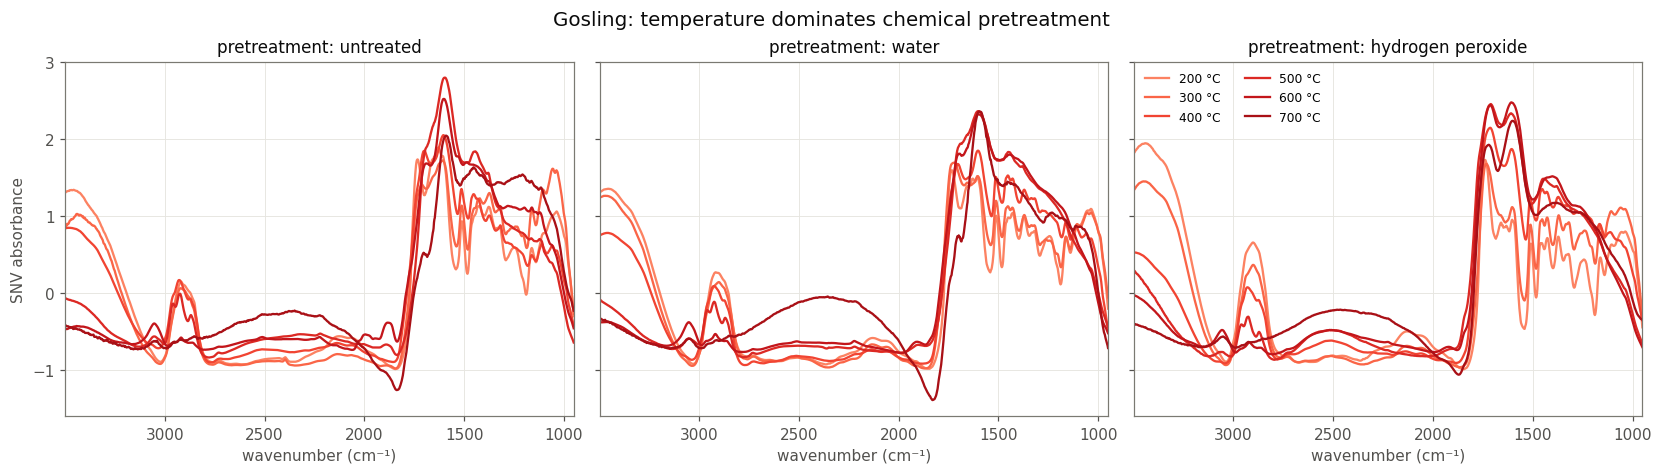

share of aromatization-index variance explained by temperature: 63.5%
share explained by pretreatment:                                2.4%


In [10]:
wm = H["wdg"]["meta"]
Xw = H["wdg"]["X"]
treatments = [t for t in ["untreated", "water", "hydrogen peroxide"]
              if (wm["treatment"] == t).any()]

fig, axes = plt.subplots(1, len(treatments), figsize=(5 * len(treatments), 4.2),
                         constrained_layout=True, sharey=True)
for ax, t in zip(np.atleast_1d(axes), treatments):
    for temp in sorted(wm["temp_c"].dropna().unique()):
        m = ((wm["treatment"] == t) & (wm["temp_c"] == temp)).to_numpy()
        if m.sum():
            ax.plot(grid, Xw[m].mean(0), color=temp_color(temp), lw=1.5,
                    label=f"{temp:.0f} °C")
    ax.set_title(f"pretreatment: {t}", color=INK)
    ax.set_xlim(grid.max(), grid.min())
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
np.atleast_1d(axes)[0].set_ylabel("SNV absorbance", color=INK2)
np.atleast_1d(axes)[-1].legend(fontsize=8, ncol=2)
fig.suptitle("Gosling: temperature dominates chemical pretreatment", fontsize=13, color=INK)
fig.savefig(PLOT_DIR / "06_pretreatment.png", dpi=160, bbox_inches="tight")
plt.show()

# Quantify it: variance in the aromatization index explained by temperature vs treatment.
wdg_idx = pd.DataFrame({
    "temp_c": wm["temp_c"],
    "treatment": wm["treatment"],
    "index": band_area(Xw, grid, BANDS["aromatic C=C"]) - band_area(Xw, grid, BANDS["aliphatic CH stretch"]),
}).dropna(subset=["temp_c", "treatment"])
total = wdg_idx["index"].var()
by_temp = wdg_idx.groupby("temp_c")["index"].transform("mean").var() / total
by_treat = wdg_idx.groupby("treatment")["index"].transform("mean").var() / total
print(f"share of aromatization-index variance explained by temperature: {by_temp:.1%}")
print(f"share explained by pretreatment:                                {by_treat:.1%}")

## 7. Band summary table

Mean SNV intensity in each diagnostic window, by collection and temperature — the
table backing every figure above (and the relief for the three palette slots that sit
below 3:1 contrast on a light surface).

In [11]:
rows = []
for key in labelled_keys:
    X, meta = H[key]["X"], H[key]["meta"]
    bt = band_table(X, grid)
    bt["temp_c"] = meta["temp_c"].to_numpy()
    bt["collection"] = H[key]["label"]
    rows.append(bt)
band_summary = (pd.concat(rows, ignore_index=True).dropna(subset=["temp_c"])
                .groupby(["collection", "temp_c"]).mean().round(3).reset_index())
display(band_summary)
band_summary.to_csv(TABLE_DIR / "band_summary_by_collection_temperature.csv", index=False)

,collection,temp_c,OH / NH stretch,aromatic CH stretch,aliphatic CH stretch,carbonyl C=O,aromatic C=C,carboxylate / C-H bend,C-O / C-O-C
0,Gosling — grass/alder + Ayauchi fossil,200.0,0.927,-0.838,0.250,1.464,1.285,0.855,0.577
1,Gosling — grass/alder + Ayauchi fossil,300.0,0.678,-0.891,0.087,1.498,1.371,1.014,0.883
2,Gosling — grass/alder + Ayauchi fossil,400.0,0.214,-0.810,-0.021,1.673,1.862,1.268,0.722
3,Gosling — grass/alder + Ayauchi fossil,500.0,-0.444,-0.646,-0.323,1.588,2.463,1.648,0.656
4,Gosling — grass/alder + Ayauchi fossil,600.0,-0.535,-0.433,-0.637,1.665,2.406,1.630,0.763
5,Gosling — grass/alder + Ayauchi fossil,700.0,-0.600,-0.601,-0.616,0.872,2.160,1.368,0.920
6,Maezumi — modern analogue reference,200.0,0.234,-0.873,0.003,1.510,1.755,1.311,0.902
7,Maezumi — modern analogue reference,300.0,0.111,-0.872,-0.022,1.483,1.840,1.330,1.036
8,Maezumi — modern analogue reference,400.0,0.077,-0.726,-0.066,1.641,2.001,1.383,0.759
9,Maezumi — modern analogue reference,500.0,-0.462,-0.644,-0.377,1.365,2.427,1.738,0.704


## Takeaways

- **The archive is internally consistent.** Four independent studies, 27 species and
  feedstocks, three laboratories and two sample-presentation geometries all show the
  same charring trajectory once SNV is applied. That is the precondition for using any
  of it as a reference series.
- **But the trajectory is not monotonic, and that is the single most important result
  here.** O–H/N–H and aliphatic C–H fall monotonically — then *saturate* near −0.6 SNV
  units by about 500–600 °C. Aromatic C=C rises to a peak between 300 and 500 °C and
  then falls, hard. The turnover is not a baseline artifact — removing each collection's
  residual slope leaves every peak temperature unchanged. So the archive resolves temperature well below ~500 °C and poorly
  above it, and any single band index maps one value onto two possible temperatures.
  `char_02` therefore reports an implied-temperature *range*, never a point estimate.
- **SNV is not optional, and it is sufficient.** The raw collections differ by ~30× in
  absolute absorbance for purely instrumental reasons. Two of the six were published
  already SNV-normalized, which fixes the common footing for free — and means no
  information is being thrown away that the source papers themselves retained.
- **Temperature dominates pretreatment** in the one collection that tests both
  (section 6), which is what licenses pooling across studies that prepared their
  material differently.
- **Coverage below 950 cm⁻¹ is thin.** Only the two McCall workbooks extend into the
  600–950 cm⁻¹ region where aromatic C–H out-of-plane bending lives. Any analysis
  needing that region is restricted to 240 spectra of the 5,889.
- **Two collections are unlabeled by design** and must never be folded into a
  temperature summary — they are prediction targets, and in `char_02` they play the
  same role Addis does: unknown material to be placed against the reference series.

Next: `char_02` puts the Addis Ababa filter spectra into this space.